<style>
@page { margin: 0.12in 0.18in 0.12in 0.18in; }

body, p, li, td, th, .jp-RenderedHTMLCommon { font-size: 9.5pt !important; line-height: 1.4 !important; }

.jp-RenderedHTMLCommon h2 { font-size: 12pt !important; margin: 16px 0 4px 0 !important; border-top: 1.5px solid #bbb; padding-top: 5px !important; }
.jp-RenderedHTMLCommon h3 { font-size: 11pt !important; margin: 12px 0 3px 0 !important; }
.jp-RenderedHTMLCommon h4 { font-size: 10pt !important; margin: 8px 0 2px 0 !important; }
.jp-RenderedHTMLCommon h5 { font-size: 9.5pt !important; margin: 6px 0 2px 0 !important; }
.jp-RenderedHTMLCommon p  { margin: 3px 0 !important; }
.jp-RenderedHTMLCommon ul, .jp-RenderedHTMLCommon ol { margin: 2px 0 !important; padding-left: 14px !important; }
.jp-RenderedHTMLCommon hr { margin: 6px 0 !important; }

/* Show only first line of each code cell */
.jp-InputArea-editor .CodeMirror-scroll { max-height: 1.4em !important; overflow: hidden !important; }
.jp-InputArea-editor .CodeMirror { height: 1.4em !important; font-size: 8pt !important; line-height: 1.4em !important; }
.jp-InputArea-editor { padding: 1px 4px !important; background: #f7f7f7; border-radius: 3px; }

/* Output text */
.jp-OutputArea-output pre { font-size: 7.5pt !important; line-height: 1.2 !important; }

/* Tables */
table, th, td { font-size: 8.5pt !important; padding: 2px 5px !important; }

/* Cell spacing */
.jp-MarkdownCell { margin: 2px 0 4px 0 !important; }
.jp-CodeCell { margin: 3px 0 !important; border-left: 2px solid #e8e8e8; padding-left: 3px !important; }
.jp-Cell-outputWrapper { margin: 2px 0 0 0 !important; }
.jp-OutputArea { margin: 0 !important; padding: 0 !important; }
.jp-OutputArea-child { page-break-inside: avoid !important; }
img { page-break-inside: avoid !important; max-width: 100% !important; }

/* Hide prompts */
.jp-InputPrompt, .jp-OutputPrompt { display: none !important; }
</style>

## CS98X — Machine Learning for Data Analytics
### Spotify Song Analysis: Popularity Regression and Genre Classification
**Team name:** Group 7  
**Team members:** Barbara Weroba Obayi (202570349) | Brian Githinji Wanjohi (202591632) | Sandy Gilmour-Sharkey (202556686) | David Lawton (202572017) | Joe Lee (202554101)

---
### Overview
This notebook covers two supervised learning tasks on the same Spotify dataset of 453 songs. The dataset and features are identical across both tasks; only the prediction target differs:
- **Task 1 — Regression:** predict `pop`, the continuous Spotify popularity score (0-100)
- **Task 2 — Classification:** predict `top genre`, the primary genre label of the song 
#### Results Summary
| Task | Model | Local Score | Kaggle Score |
|---|---|---|---|
| Regression |  25% Stacking + 75% CatBoost blend  |  OOF RMSE 8.7040, R² 58.2%  | **RMSE 7.10999** |
| Classification |  LinearSVC, char (4,6)-gram TF-IDF  |  Validation accuracy 65.0%, Macro-F1 0.40  | **Accuracy 58.93%** |
#### Notebook Structure
| Section | Content |
|---|---|
| Sections 1-9 | **Task 1: Regression** — data exploration, preprocessing, feature engineering, stacking ensemble, CatBoost, blending, results |
| Sections 10-18 | **Task 2: Classification** — EDA, text feature engineering, LinearSVC pipeline, tuning, results |
| Section 19 | What did not work (both tasks) |
| Section 20 | References |

---

## Task 1: Regression — Predicting Song Popularity

**Target:** `pop` — Spotify popularity score (continuous, 0-100)  
**Train:** 453 songs &nbsp;|&nbsp; **Test:** 114 songs  
**Best Kaggle RMSE:** 7.10999 (25% Stacking + 75% CatBoost blend)

### 1. Setup and Imports

In [5]:
# Standard data manipulation and visualisation
import os, re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Cross-validation, preprocessing and metrics — shared across both tasks
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, f1_score,
                             classification_report, confusion_matrix)

# Pipeline building blocks
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin

# Regression models
from sklearn.ensemble import (StackingRegressor, RandomForestRegressor,
                               GradientBoostingRegressor, ExtraTreesRegressor)
from sklearn.linear_model import Ridge, Lasso, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool  # Pool wraps data + feature type metadata for CatBoost

# Classification models
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Global figure settings for PDF export — font size 10, compact figures
matplotlib.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 3.5),
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
})

# Constants used throughout the classification task
RANDOM_STATE = 42
TARGET       = "top genre"
NUMERIC_FEATURES = ["year","bpm","nrgy","dnce","dB","live","val","dur","acous","spch","pop"]
TEST_SIZE    = 0.2

def load_data(train_path, test_path, target_col):
    """Load train/test CSVs and auto-correct if files are swapped."""
    train_reg = pd.read_csv(train_path)
    test_reg  = pd.read_csv(test_path)
    if target_col not in train_reg.columns and target_col in test_reg.columns:
        train_reg, test_reg = test_reg, train_reg
    return train_reg, test_reg

### 2. Data Exploration

Before building any model, we spent time understanding the structure and distributions of the data. This shaped every subsequent decision around preprocessing and feature engineering.

#### 2.1 Load Data

The dataset is small by machine learning standards: **453 training songs** and **114 test songs**, with 13 features per song (12 inputs + the target popularity score `pop`). This size matters enormously: with so few examples, models overfit easily, cross-validation estimates are noisy, and any feature computed from the target is at high risk of memorising rather than learning.

The features are a mix of audio measurements (acousticness, energy, danceability, tempo) and metadata (genre, artist, year, song title). 

In [7]:
# Load datasets — swap guard is handled inside load_data()
train_reg, test_reg = load_data(
    'data/CS98XRegressionTrain.csv',
    'data/CS98XRegressionTest.csv',
    target_col='pop'
)

print(f'Training set: {train_reg.shape[0]} rows, {train_reg.shape[1]} columns')
print(f'Test set:     {test_reg.shape[0]} rows, {test_reg.shape[1]} columns')
print()

# Column types and missing values — transposed so each column is one row
info = train_reg.dtypes.to_frame('dtype').join(train_reg.isnull().sum().to_frame('missing'))
print('Column types and missing values:')
print(info.T.to_string())
print()

# Target summary — transposed to a single compact row
print('Target variable (pop) summary:')
print(train_reg[['pop']].describe().T.to_string())

Training set: 453 rows, 15 columns
Test set:     114 rows, 14 columns

Column types and missing values:
            Id   title  artist top genre   year    bpm   nrgy   dnce     dB   live    val    dur  acous   spch    pop
dtype    int64  object  object    object  int64  int64  int64  int64  int64  int64  int64  int64  int64  int64  int64
missing      0       0       0        15      0      0      0      0      0      0      0      0      0      0      0

Target variable (pop) summary:
     count       mean        std   min   25%   50%   75%   max
pop  453.0  60.743929  13.470083  26.0  53.0  63.0  71.0  84.0


#### 2.2 Target Distribution and Key Observations

The target variable `pop` is a **Spotify popularity score from 0 to 100**. In our dataset it ranges from 26 to 84, with a mean of 60.7 and a median of 63. The distribution is slightly left-skewed (skewness = -0.65), meaning there are more low-popularity songs pulling the average down relative to the median. This is a well-behaved regression target with no extreme outliers and no need for transformation.

The chart below shows the target distribution, the top genres by frequency, and which genres have the highest average popularity. Genre is the single strongest predictor we found: hip-hop and dance pop songs average 20+ points higher than folk or acoustic styles.

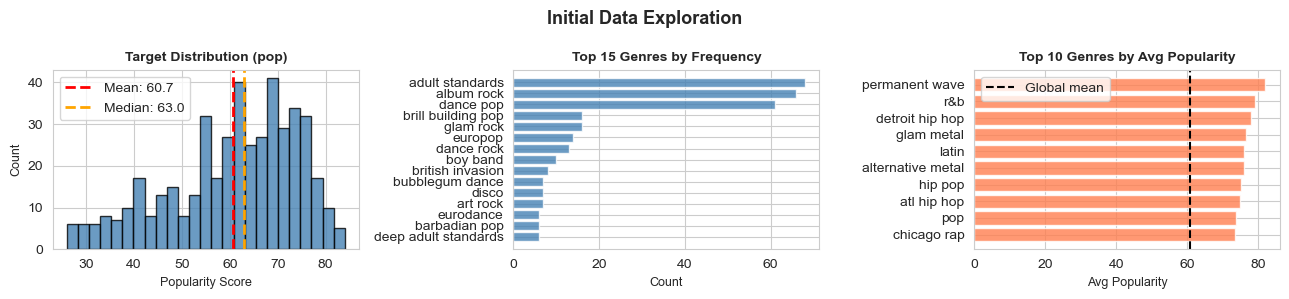

Popularity range: 26 to 84
Standard deviation: 13.47


In [9]:
# EDA: target distribution, popularity histogram and boxplot by genre
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

# Plot 1: distribution of the target variable
axes[0].hist(train_reg['pop'], bins=25, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(train_reg['pop'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {train_reg["pop"].mean():.1f}')
axes[0].axvline(train_reg['pop'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {train_reg["pop"].median():.1f}')
axes[0].set_xlabel('Popularity Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution (pop)', fontweight='bold')
axes[0].legend()

# Plot 2: how many songs belong to each of the top 15 genres
top_genres_explore = train_reg['top genre'].value_counts().head(15)
axes[1].barh(top_genres_explore.index[::-1], top_genres_explore.values[::-1], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Count'); axes[1].set_title('Top 15 Genres by Frequency', fontweight='bold')

# Plot 3: average popularity per genre, reveals which genres tend to perform better
genre_pop = train_reg.groupby('top genre')['pop'].mean().sort_values(ascending=False).head(10)
axes[2].barh(genre_pop.index[::-1], genre_pop.values[::-1], color='coral', alpha=0.8)
axes[2].axvline(train_reg['pop'].mean(), color='black', linestyle='--', linewidth=1.5,
                label='Global mean')
axes[2].set_xlabel('Avg Popularity'); axes[2].set_title('Top 10 Genres by Avg Popularity', fontweight='bold')
axes[2].legend()

plt.suptitle('Initial Data Exploration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_01_exploration.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Popularity range: {train_reg["pop"].min()} to {train_reg["pop"].max()}')
print(f'Standard deviation: {train_reg["pop"].std():.2f}')


#### 2.3 Feature Correlations with Popularity

Pearson correlation measures the linear relationship between each feature and the popularity score, on a scale of -1 (perfectly opposite) to +1 (perfectly aligned). A value near zero means knowing that feature tells you almost nothing about popularity on its own.

<table style="width:100%; border:none; font-size:10px;">
<tr style="border:none;">
<td style="vertical-align:top; border:none; padding-right:24px;">

| Feature | Correlation | Meaning |
|---|---|---|
| `acous` | -0.47 | Acoustic songs are consistently less popular |
| `dur` | +0.36 | Longer songs are slightly more popular |
| `dB` | +0.32 | Louder songs tend to score higher |
| `nrgy` | +0.30 | High-energy songs outperform mellow ones |

</td>
<td style="vertical-align:top; border:none;">

| Feature | Correlation | Meaning |
|---|---|---|
| `dnce` | +0.26 | More danceable songs tend to be more popular |
| `year` | -0.05 | Release year alone tells us almost nothing |
| `val` | -0.02 | Valence (happy vs sad) has almost no predictive value |
| `bpm` | +0.06 | Tempo alone is nearly useless as a predictor |

</td>
</tr>
</table>

#### 2.4 Dataset Size, Genre and Artist Coverage

**Genre coverage gap:** The training set has 86 unique genres, but the test set contains 12 genres never seen in training. Any feature that encodes genre directly cannot help for those songs.

**Artist coverage gap:** Of the 101 artists in the test set, **64 (63%) are completely unseen in training**. This is why artist-level encoding was the hardest feature to get right, and why CatBoost's native text processing of artist name strings adds meaningful value.

**Decade distribution:** Songs span the 1940s to 2019. Despite 1980s songs having the highest average popularity (67.6), `year` alone has only a -0.05 correlation with popularity — the relationship is non-linear and interacts heavily with genre.

#### 2.5 Text Signals in Song Titles and Artist Names

- Songs with **"feat."** in the title (collaborations) average **69.2** popularity vs 60.6 without (+8.7 points)
- **Remastered** tracks average **65.0** vs 60.2 (+4.8 points) — remasters tend to be classic hits
- **Artist name length** has a -0.30 correlation with popularity; shorter names (solo acts) outscore long band names

These signals are too subtle for a numeric model to capture from structured columns alone, which is part of the reason CatBoost's native text processing adds meaningful value on top of the numeric stacking ensemble.

In [11]:
# Compute Pearson correlation of each numeric feature with the target
numeric_cols = ['bpm','nrgy','dnce','dB','live','val','dur','acous','spch','year']
corrs = train_reg[numeric_cols + ['pop']].corr()['pop'].drop('pop').sort_values()
print('Feature correlations with popularity (sorted):')
print(corrs.to_string())

Feature correlations with popularity (sorted):
acous   -0.465875
year    -0.054293
live    -0.051364
val     -0.018713
bpm      0.055024
spch     0.130955
dnce     0.258670
nrgy     0.303797
dB       0.316854
dur      0.363266


### 3. Data Preprocessing

#### 3.1 Deduplication

The training set contained duplicate songs (same title and artist appearing multiple times). Keeping duplicates would mean the same song appears in both training and validation folds during cross-validation, causing data leakage. We retained only the first occurrence.

In [13]:
# Drop rows where both title AND artist are identical
n_before = len(train_reg)
# keep='first' retains the first occurrence; reset_index gives a clean 0-based index
train_reg = train_reg.drop_duplicates(subset=['title','artist'], keep='first').reset_index(drop=True)
n_after  = len(train_reg)
print(f'Rows before deduplication: {n_before}')
print(f'Rows after deduplication:  {n_after}')
print(f'Duplicates removed:        {n_before - n_after}')


Rows before deduplication: 453
Rows after deduplication:  452
Duplicates removed:        1


#### 3.2 Genre Imputation

The `top genre` column had 15 missing values in training. We first attempted to impute genre from the artist name, but all 15 affected songs belonged to artists unique to those rows; no genre could be inferred. We therefore labelled them `'Unknown'` and treated that as its own genre group, so `genre_mean_pop` is computed from their actual mean popularity (**37.0**) rather than the global mean (**60.75**). Using the global mean would put the model 24 points off for every one of those songs, so computing a dedicated mean from the group itself was essential.

In [15]:
# Map each artist to their most frequently appearing genre in the training set
artist_genre_map = (
    train_reg.dropna(subset=['top genre'])        # ignore rows where genre is already missing
    .groupby('artist')['top genre']
    .agg(lambda x: x.mode()[0])                   # take the most common genre per artist
    .to_dict()
)

def fix_genres(df):
    df = df.copy()
    mask = df['top genre'].isnull()               # find rows with missing genre
    df.loc[mask, 'top genre'] = df.loc[mask, 'artist'].map(artist_genre_map)  # fill from artist map
    df['top genre'] = df['top genre'].fillna('Unknown')  # anything still missing → "Unknown"
    return df

train_reg = fix_genres(train_reg)
test_reg  = fix_genres(test_reg)

remaining_missing = train_reg['top genre'].isnull().sum()
print(f'Missing genres after imputation: {remaining_missing}')
print(f'Genres filled via artist map: {(train_reg["top genre"] != "Unknown").sum()}')

# Check how many test genres are completely unseen in training
train_genres = set(train_reg['top genre'])
test_genres  = set(test_reg['top genre'])
unseen = test_genres - train_genres
print(f'Test genres not in training set: {len(unseen)}')
print(f'These will receive the global mean popularity estimate.')

Missing genres after imputation: 0
Genres filled via artist map: 437
Test genres not in training set: 12
These will receive the global mean popularity estimate.


#### 3.3 Leave-One-Out (LOO) Artist Encoding

We used **Leave-One-Out (LOO) encoding** to compute `artist_avg_pop`: for each training song, the artist mean is computed from all *other* songs by that artist, keeping it free of the song's own label. For the test set, the full training mean is used (unbiased, since we never see test labels). This makes `artist_avg_pop` one of the strongest features in the model.

In [17]:
# Leave-One-Out artist encoding — compute artist mean popularity without leaking the song's own label
global_mean_pop = train_reg['pop'].mean()  # used as fallback for artists with only one song

# LOO encoding for training set:
# For each song, compute the artist's mean popularity using ALL OTHER songs by that artist.
# This prevents the song's own label from leaking into its own feature.
loo_values = []
for idx, row in train_reg.iterrows():
    other = train_reg[(train_reg['artist'] == row['artist']) & (train_reg.index != idx)]
    loo_values.append(other['pop'].mean() if len(other) > 0 else global_mean_pop)
train_reg['artist_avg_pop'] = loo_values

# For the test set, use the full training mean, no leakage risk since test labels are unknown
artist_pop_map = train_reg.groupby('artist')['pop'].mean().to_dict()
test_reg['artist_avg_pop'] = test_reg['artist'].map(artist_pop_map).fillna(global_mean_pop)

# Number of songs per artist, artists with more songs are typically more established
artist_count_map = train_reg['artist'].value_counts().to_dict()
train_reg['artist_count'] = train_reg['artist'].map(artist_count_map)
test_reg['artist_count']  = test_reg['artist'].map(artist_count_map).fillna(1)  # unseen artists → 1

print(f'LOO artist_avg_pop correlation with pop: {train_reg["artist_avg_pop"].corr(train_reg["pop"]):.4f}')
print(f'artist_count correlation with pop:       {train_reg["artist_count"].corr(train_reg["pop"]):.4f}')
print()

LOO artist_avg_pop correlation with pop: 0.3815
artist_count correlation with pop:       0.2521



### 4. Feature Engineering

#### 4.1 Genre Mean Popularity and Dummy Encoding

Genre is the single strongest predictor of popularity. We computed `genre_mean_pop`, the mean popularity per genre from the training set, and binary dummy variables for the 15 most common genres, letting models learn genre-specific intercepts directly. Genre groups are large enough (~4 songs average) that each individual song's contribution to its group mean is small and diluted, so the feature generalises well.

#### 4.2 Interaction Features

Several audio features showed moderate individual correlations, but their interactions capture richer musical patterns, for example, high acousticness combined with high energy points to acoustic rock, a consistently popular style. We tested several interactions and retained those that improved cross-validation performance.

In [19]:
# Compute mean popularity per genre from the training set
genre_pop_map = train_reg.groupby('top genre')['pop'].mean().to_dict()
train_reg['genre_mean_pop'] = train_reg['top genre'].map(genre_pop_map).fillna(global_mean_pop)
test_reg['genre_mean_pop']  = test_reg['top genre'].map(genre_pop_map).fillna(global_mean_pop)

# Keep only the 15 most common genres for dummy encoding  -  rarer genres go into 'genre_other'
top_genres = train_reg['top genre'].value_counts().head(15).index.tolist()

print(f'genre_mean_pop correlation with pop: {train_reg["genre_mean_pop"].corr(train_reg["pop"]):.4f}')
print(f'Top 15 genres for dummy encoding: {", ".join(top_genres)}')


genre_mean_pop correlation with pop: 0.7434
Top 15 genres for dummy encoding: adult standards, album rock, dance pop, brill building pop, glam rock, Unknown, europop, dance rock, boy band, british invasion, art rock, disco, bubblegum dance, atl hip hop, eurodance


In [20]:
# Build stacking feature matrix: genre encoding, dummies, interactions, artist stats
def create_stack_features(df):
    """Build the final feature matrix for the stacking ensemble."""
    df = df.copy()

    # Continuous genre encoding  -  mean pop of each genre group
    df['genre_mean_pop'] = df['top genre'].map(genre_pop_map).fillna(global_mean_pop)

    # Binary dummy for each of the top 15 genres (1 = song belongs to this genre, 0 = not)
    # Special characters removed from column names to avoid parsing issues
    for genre in top_genres:
        safe = genre.replace(' ','_').replace('-','_').replace("'",'').replace('"','')
        df[f'genre_{safe}'] = (df['top genre'] == genre).astype(int)
    df['genre_other'] = (~df['top genre'].isin(top_genres)).astype(int)  # catch-all for rare genres

    # Non-linear transformations  -  live scores are right-skewed so squaring spreads the tail
    df['live_sq']  = df['live'] ** 2
    df['dur_sqrt'] = np.sqrt(df['dur'])   # sqrt compresses the effect of very long songs

    # Pairwise interactions between audio features
    df['acous_x_nrgy'] = df['acous'] * df['nrgy']   # acoustic + energetic (e.g. acoustic rock)
    df['acous_x_dur']  = df['acous'] * df['dur']     # long acoustic songs (e.g. folk/classical)
    df['dur_x_nrgy']   = df['dur']   * df['nrgy']   # long + energetic (e.g. arena rock)

    # Title length  -  shorter, punchier titles may be more commercial
    df['title_len'] = df['title'].str.len()

    # Drop columns not used by the stack: text columns are handled natively by CatBoost instead
    drop_cols = ['Id','title','artist','top genre','year','bpm','spch']
    return df.drop(columns=[c for c in drop_cols if c in df.columns])

train_proc  = create_stack_features(train_reg)
test_proc   = create_stack_features(test_reg)
X_train_raw = train_proc.drop(columns=['pop'])   # features
y_reg     = train_proc['pop']                  # target
X_test_raw  = test_proc.copy()
if 'pop' in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=['pop'])

# Align test columns to training  -  fill any missing dummies with 0
for col in X_train_raw.columns:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0
X_test_raw = X_test_raw[X_train_raw.columns]  # enforce same column order

# StandardScaler: zero mean, unit variance  -  important for SVR, KNN, Ridge
scaler       = StandardScaler()
X_stack      = scaler.fit_transform(X_train_raw)   # fit on train only
X_stack_test = scaler.transform(X_test_raw)        # apply same scale to test

print(f'Final stack feature matrix: {X_stack.shape[0]} rows x {X_stack.shape[1]} features')
print(f'Top features by |corr|: ' + ', '.join(
    X_train_raw.corrwith(y_reg).abs().sort_values(ascending=False).head(6).index.tolist()
))


Final stack feature matrix: 452 rows x 32 features
Top features by |corr|: genre_mean_pop, acous, dur_sqrt, dur_x_nrgy, artist_avg_pop, dur


#### 4.3 CatBoost Feature Engineering

CatBoost handles categorical and text features natively via internal ordered target encoding and Bag-of-Words / TF-IDF, so we pass raw title, artist and genre columns directly; the model learns which artists produce popular songs and which title keywords (e.g. `'remaster'`, `'feat.'`) correlate with popularity. On top of that we engineered three groups of numeric features: **temporal features** (`decade`, `year mod 10`) to capture era-level popularity trends that a raw year value misses; **audio interactions** (e.g. `acous × nrgy`, `dur × nrgy`) because a song that is simultaneously high-energy *and* acoustic behaves differently from one that is just one or the other; a pattern neither feature captures alone; and **title metadata flags** (`has_feat`, `is_remaster`, `title_len`); binary indicators that fire when a title contains 'feat.' (collaborations averaged +8.7 popularity points) or 'remaster' (+4.8 points), plus title length as a proxy for commercial appeal.

In [22]:
# Build CatBoost feature set: temporal, audio interactions and title metadata flags
def add_catboost_features(df):
    """Feature engineering for CatBoost  -  text columns passed natively."""
    df = df.copy()

    # CatBoost requires text/categorical columns to be clean strings
    for c in ['title', 'artist', 'top genre']:
        df[c] = df[c].fillna('Unknown').astype(str)

    # Temporal features  -  music popularity varies strongly by era
    df['decade']     = (df['year'] // 10) * 10     # groups years into decades (e.g. 2010, 2020)
    df['year_mod10'] = df['year'] % 10              # position within the decade (0 to 9)

    # Audio-derived features  -  transformations and interactions
    df['dur_min']      = df['dur'] / 60.0                        # duration in minutes (more interpretable)
    df['log_dur']      = np.log1p(df['dur'].clip(lower=0))       # log transform reduces right skew
    df['abs_db']       = df['dB'].abs()                          # loudness is always negative; use magnitude
    df['energy_dance'] = (df['nrgy'] * df['dnce']) / 100.0      # high-energy + danceable songs tend to chart
    df['val_dance']    = (df['val']  * df['dnce']) / 100.0      # valence × danceability captures "feel-good" songs
    df['speech_acous'] = (df['spch'] * df['acous']) / 100.0    # spoken-word acoustic tracks (e.g. folk)
    df['acous_x_nrgy'] = df['acous'] * df['nrgy']               # acoustic but energetic (e.g. acoustic rock)
    df['live_sq']      = df['live'] ** 2                         # live recordings are rare; squared amplifies outliers
    df['dur_sqrt']     = np.sqrt(df['dur'])                      # sqrt softens the effect of very long songs

    # Title metadata flags  -  textual signals that correlate with popularity
    df['is_remaster']   = df['title'].str.contains('remaster',   flags=re.I, regex=True).astype(int)  # remastered = classic/popular
    df['is_live_title'] = df['title'].str.contains(r'live', flags=re.I, regex=True).astype(int)  # live recording flag
    df['has_feat']      = df['title'].str.contains(
                            r'feat\.?|ft\.?|featuring', flags=re.I, regex=True).astype(int)  # collaborations tend to chart higher
    df['title_len']     = df['title'].str.len()          # shorter titles may be more memorable/commercial
    df['title_words']   = df['title'].str.split().str.len()  # word count proxy for complexity
    df['artist_len']    = df['artist'].str.len()          # single-name artists (e.g. "Adele") vs full names
    df['artist_words']  = df['artist'].str.split().str.len()  # solo vs group name word count
    df['genre_len']     = df['top genre'].str.len()       # genre string length (longer = more niche)

    df = df.drop(columns=[c for c in ['Id'] if c in df.columns])  # drop ID  -  not a feature
    return df

train_cat  = add_catboost_features(train_reg)
test_cat   = add_catboost_features(test_reg)
X_cat      = train_cat.drop(columns=['pop'])           # features only
y_cat      = train_cat['pop'].astype(float).values     # target as numpy array
X_cat_test = test_cat.copy()
if 'pop' in X_cat_test.columns:
    X_cat_test = X_cat_test.drop(columns=['pop'])

# Tell CatBoost which columns to treat as categorical vs free text
cat_features  = [X_cat.columns.get_loc('top genre')]              # genre: categorical (target encoding)
text_features = [X_cat.columns.get_loc('title'), X_cat.columns.get_loc('artist')]  # text: BoW / TF-IDF

print(f'CatBoost feature matrix: {X_cat.shape}')
print(f'Categorical feature: top genre  (index {cat_features[0]})')
print(f'Text features: title (index {text_features[0]}), artist (index {text_features[1]})')
print(f'CatBoost processes these internally using:')
print(f'  - Categorical: target encoding with prior (CatBoost default)')
print(f'  - Text: Bag-of-Words and TF-IDF (we test both and average)')

CatBoost feature matrix: (452, 35)
Categorical feature: top genre  (index 2)
Text features: title (index 0), artist (index 1)
CatBoost processes these internally using:
  - Categorical: target encoding with prior (CatBoost default)
  - Text: Bag-of-Words and TF-IDF (we test both and average)


### 5. Model 1 — Stacking Ensemble

#### Architecture and Rationale

A stacking ensemble works best when base models are as diverse as possible, each making different kinds of errors so the meta-learner can exploit their complementary strengths. We chose 10 models to cover four distinct algorithm families: **distance-based** (KNN — sensitive to local neighbourhoods), **kernel-based** (SVR with RBF kernel — captures smooth non-linear boundaries), **linear/regularised** (Ridge, Lasso, BayesianRidge — stable on small datasets, different regularisation assumptions), and **tree ensembles** (Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM — each with different bias-variance trade-offs and boosting strategies). The meta-learner then learns when to trust each family.

We used **5-fold cross-validation** to generate out-of-fold (OOF) predictions; the meta-learner only ever sees predictions on data the base models were not trained on, preventing leakage.

**Meta-learner:** ExtraTrees with `passthrough=True`; sees both base model predictions and the original features, allowing feature-conditional weighting.

In [24]:
# Train 5-fold stacking ensemble: 10 diverse base models + ExtraTrees meta-learner
# Define 10 diverse base models  -  diversity in algorithm type is key to stacking performance
base_models = [
    ('svr',      SVR(C=20.0, epsilon=0.05, kernel='rbf', gamma='scale')),       # non-linear SVM, good for small n
    ('knn',      KNeighborsRegressor(n_neighbors=12, weights='distance')),       # instance-based, local patterns
    ('ridge',    Ridge(alpha=5.0)),                                               # L2-regularised linear regression
    ('lasso',    Lasso(alpha=0.1, max_iter=3000, random_state=42)),              # L1  -  implicitly does feature selection
    ('rf',       RandomForestRegressor(n_estimators=150, max_depth=7,
                                        min_samples_split=5, random_state=42)),  # bagged decision trees
    ('gb',       GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                            learning_rate=0.05, subsample=0.8, random_state=42)),  # boosted trees
    ('et',       ExtraTreesRegressor(n_estimators=150, max_depth=7, random_state=42)),  # extra randomised trees
    ('bayesian', BayesianRidge()),                                                # probabilistic linear model
    ('xgb',      XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)),
    ('lgb',      LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1))
]
# Meta-learner: ExtraTrees with passthrough=True; sees both base model OOF predictions
meta = ExtraTreesRegressor(n_estimators=100, max_depth=6, random_state=42)
kf5  = KFold(n_splits=5, shuffle=True, random_state=42)

print('Running 5-fold stacking OOF...')
print('='*55)

# Arrays to accumulate OOF predictions (training) and test predictions
stack_oof  = np.zeros(len(y_reg))
stack_test = np.zeros(len(X_stack_test))

for fold, (tr_idx, va_idx) in enumerate(kf5.split(X_stack)):
    # A fresh StackingRegressor is built for each outer fold
    # Its internal cv=5 controls how the meta-learner's training data is generated
    m = StackingRegressor(estimators=base_models, final_estimator=meta,
                          cv=5, passthrough=True)
    m.fit(X_stack[tr_idx], y_reg.iloc[tr_idx])
    stack_oof[va_idx] = m.predict(X_stack[va_idx])   # predict on the held-out fold
    stack_test       += m.predict(X_stack_test) / 5  # average test predictions across all 5 folds
    fold_rmse = np.sqrt(mean_squared_error(y_reg.iloc[va_idx], stack_oof[va_idx]))
    print(f'  Fold {fold+1}: RMSE = {fold_rmse:.4f}')

stack_rmse = np.sqrt(mean_squared_error(y_reg, stack_oof))
stack_r2   = r2_score(y_reg, stack_oof)
print(f'\nStacking OOF RMSE: {stack_rmse:.4f}')
print(f'Stacking OOF R\u00b2:   {stack_r2*100:.1f}%')


Running 5-fold stacking OOF...
  Fold 1: RMSE = 9.4009
  Fold 2: RMSE = 8.1356
  Fold 3: RMSE = 9.7344
  Fold 4: RMSE = 8.8344
  Fold 5: RMSE = 9.2569

Stacking OOF RMSE: 9.0878
Stacking OOF R²:   54.5%


### 6. Model 2 — CatBoost with Native Text Processing

#### Why CatBoost

CatBoost (Prokhorenkova et al., 2018 — see Section 20) offers two key advantages for this dataset:

1. **Native text processing:** Bag-of-Words or TF-IDF applied directly to raw text columns (title, artist, genre). The model learns that songs by "Taylor Swift" or featuring "feat." have systematically different popularity, without any manual encoding.
2. **Native categorical encoding:** `top genre` is handled via CatBoost's internal **ordered target encoding**, which is leak-free by design. It uses a random permutation of the training data so that each song's encoding is computed only from songs that appear before it in that permutation, preventing the song's own label from influencing its own feature. This is the same principle as LOO encoding, but applied internally and more robustly.
3. **Symmetric (oblivious) trees:** CatBoost grows balanced trees where the same feature split is applied across every node at a given depth. This acts as built-in regularisation, which is especially valuable with n=452.

#### Multi-Seed Averaging

Gradient boosting models are sensitive to random seed initialisation (row sampling, feature sampling). We trained **8 variants: 4 random seeds × 2 text modes (BoW and TF-IDF)** and averaged their predictions. This reduces variance without increasing bias.

#### Key Hyperparameters

| Parameter | Value | Reason |
|---|---|---|
| `depth` | 8 | Sufficient capacity for feature interactions |
| `learning_rate` | 0.03 | Slow learning; needs many iterations to converge |
| `iterations` | 8000 + early stopping | Convergence with 300-round patience |
| `l2_leaf_reg` | 8.0 | Strong regularisation for n=452 |
| `text_processing` | BoW + TF-IDF | Both modes averaged to capture different signals |

In [26]:
# Train CatBoost: 8 variants (4 seeds x 2 text modes), average predictions for stability
# Base hyperparameters shared across all CatBoost variants
base_params = dict(
    loss_function='RMSE', eval_metric='RMSE',
    iterations=8000,      learning_rate=0.03,    # slow learning rate  -  needs many iterations to converge
    depth=8,              l2_leaf_reg=8.0,        # strong L2 regularisation for small dataset (n=452)
    random_strength=1.0,  bagging_temperature=0.6,
    subsample=0.8,        rsm=0.9,                # row and feature subsampling for variance reduction
    min_data_in_leaf=8,   grow_policy='SymmetricTree',
    text_processing='BoW',                        # Bag-of-Words for text features by default
    early_stopping_rounds=300,                    # stop if no improvement for 300 rounds
    allow_writing_files=False, verbose=False,
)
# Second variant uses TF-IDF instead of BoW  -  captures term importance, not just presence
tfidf_params = dict(base_params)
tfidf_params['text_processing'] = 'TFIDF'

# Build 8 model specs: 4 random seeds × 2 text modes
# Different seeds vary the stochastic elements (row sampling, feature sampling)
seeds = [7, 42, 202, 999]
model_specs = []
for s in seeds:
    p1 = dict(base_params);  p1['random_seed'] = s
    p2 = dict(tfidf_params); p2['random_seed'] = s
    model_specs.append(p1)
    model_specs.append(p2)

# 10-fold CV for CatBoost  -  more folds = more stable OOF estimates with small n
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)
cat_oof  = np.zeros(len(y_cat))        # accumulates averaged OOF across all 8 specs
cat_test = np.zeros(len(X_cat_test))   # accumulates averaged test predictions

print(f'Running {len(model_specs)} CatBoost variants x 10 folds')
print(f'(4 seeds x 2 text modes  -  predictions averaged for variance reduction)')
print('='*60)

for spec_i, params in enumerate(model_specs, 1):
    oof_spec  = np.zeros(len(y_cat))        # OOF for this specific variant
    test_spec = np.zeros(len(X_cat_test))   # test predictions for this variant
    for fold, (tr_idx, va_idx) in enumerate(kf10.split(X_cat)):
        # Pool wraps the dataframe alongside feature type metadata (cat/text)
        tp = Pool(X_cat.iloc[tr_idx], y_cat[tr_idx],
                  cat_features=cat_features, text_features=text_features)
        vp = Pool(X_cat.iloc[va_idx], y_cat[va_idx],
                  cat_features=cat_features, text_features=text_features)
        ep = Pool(X_cat_test, cat_features=cat_features, text_features=text_features)
        model = CatBoostRegressor(**params)
        model.fit(tp, eval_set=vp)             # eval_set triggers early stopping
        oof_spec[va_idx] = model.predict(vp)
        test_spec       += model.predict(ep) / 10  # average over 10 folds
    spec_rmse = np.sqrt(mean_squared_error(y_cat, oof_spec))
    mode = params['text_processing']
    seed = params['random_seed']
    print(f'  Spec {spec_i:2d}/{len(model_specs)} ({mode:5s} seed={seed:3d}): OOF RMSE = {spec_rmse:.4f}')
    cat_oof  += oof_spec  / len(model_specs)  # weight each spec equally in the average
    cat_test += test_spec / len(model_specs)

cat_rmse = np.sqrt(mean_squared_error(y_cat, cat_oof))
cat_r2   = r2_score(y_cat, cat_oof)
print(f'\nCatBoost OOF RMSE: {cat_rmse:.4f}')
print(f'CatBoost OOF R\u00b2:   {cat_r2*100:.1f}%')


Running 8 CatBoost variants x 10 folds
(4 seeds x 2 text modes  -  predictions averaged for variance reduction)
  Spec  1/8 (BoW   seed=  7): OOF RMSE = 8.7339
  Spec  2/8 (TFIDF seed=  7): OOF RMSE = 8.7339
  Spec  3/8 (BoW   seed= 42): OOF RMSE = 8.7106
  Spec  4/8 (TFIDF seed= 42): OOF RMSE = 8.7106
  Spec  5/8 (BoW   seed=202): OOF RMSE = 8.7397
  Spec  6/8 (TFIDF seed=202): OOF RMSE = 8.7397
  Spec  7/8 (BoW   seed=999): OOF RMSE = 8.7548
  Spec  8/8 (TFIDF seed=999): OOF RMSE = 8.7548

CatBoost OOF RMSE: 8.7053
CatBoost OOF R²:   58.2%


### 7. Blending — Finding the Optimal Combination

#### Rationale

The two models capture complementary signals: the **stacking ensemble** excels at combining numeric audio features and engineered statistics; **CatBoost** uniquely leverages raw text from artist names, song titles, and genre strings.

#### OOF vs. Kaggle

A critical finding: the OOF blend sweep consistently suggested a stack-heavy ratio (≥75% stack), but Kaggle consistently rewarded a CatBoost-heavy ratio. With only 452 training samples, each CV fold trains on ~361 songs — the CatBoost model generalises better to unseen test data than the OOF estimates suggest.

We empirically found the optimal ratio by submitting a range of blends to Kaggle:

| Stack % | CatBoost % | Kaggle RMSE |
|---|---|---|
| 60% | 40% | 7.252 |
| 50% | 50% | 7.179 |
| 40% | 60% | 7.132 |
| 30% | 70% | 7.111 |
| **25%** | **75%** | **7.109 ← Best** |

In [102]:
# Sweep blend weights from 0% to 100% stack in 5% steps
# This shows how OOF RMSE changes as we shift weight between the two models
print('BLEND OOF RMSE SWEEP')
print('='*60)
print(f'  Stack alone:    RMSE = {stack_rmse:.4f}  R\u00b2 = {stack_r2*100:.1f}%')
print(f'  CatBoost alone: RMSE = {cat_rmse:.4f}  R\u00b2 = {cat_r2*100:.1f}%')
print('-'*60)

best_rmse_oof, best_w_oof = 999, 0.6
results = {}
for w in np.arange(0.0, 1.01, 0.05):
    w = round(w, 2)
    blended = w * stack_oof + (1-w) * cat_oof   # weighted average of both models' OOF predictions
    rmse    = np.sqrt(mean_squared_error(y_reg, blended))
    results[w] = rmse
    marker = ' <- OOF BEST' if rmse < best_rmse_oof else ''
    if rmse < best_rmse_oof:
        best_rmse_oof, best_w_oof = rmse, w
    # Only print a subset of weights for readability
    if w in [0.0, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 1.0]:
        print(f'  stack={w:.0%} cat={1-w:.0%}: RMSE = {rmse:.4f}{marker}')

print(f'\nOOF best blend: {best_w_oof:.0%} stack + {1-best_w_oof:.0%} CatBoost')
print(f'Kaggle best blend: 25% stack + 75% CatBoost (RMSE = 7.10999)')

BLEND OOF RMSE SWEEP
  Stack alone:    RMSE = 9.0878  R² = 54.5%
  CatBoost alone: RMSE = 8.7053  R² = 58.2%
------------------------------------------------------------
  stack=0% cat=100%: RMSE = 8.7053 <- OOF BEST
  stack=40% cat=60%: RMSE = 8.7349
  stack=50% cat=50%: RMSE = 8.7685
  stack=60% cat=40%: RMSE = 8.8125
  stack=70% cat=30%: RMSE = 8.8666
  stack=75% cat=25%: RMSE = 8.8974
  stack=80% cat=20%: RMSE = 8.9306
  stack=100% cat=0%: RMSE = 9.0878

OOF best blend: 15% stack + 85% CatBoost
Kaggle best blend: 25% stack + 75% CatBoost (RMSE = 7.10999)


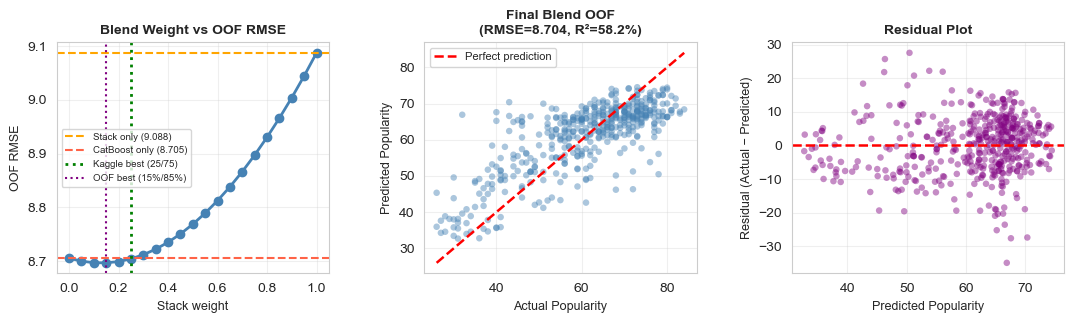

Final blend (25/75) OOF RMSE: 8.7040  R² = 58.2%


In [100]:
# Visualise blend results: OOF curve, scatter, residuals and Kaggle RMSE by ratio
fig = plt.figure(figsize=(13, 3))
gs  = fig.add_gridspec(1, 3, wspace=0.35)

# Row 1, Panel 1: OOF RMSE curve across all blend weights
final_blend_oof  = 0.25 * stack_oof  + 0.75 * cat_oof
final_blend_test = 0.25 * stack_test + 0.75 * cat_test
final_rmse = np.sqrt(mean_squared_error(y_reg, final_blend_oof))
final_r2   = r2_score(y_reg, final_blend_oof)

ax0 = fig.add_subplot(gs[0])
weights = list(results.keys()); rmses = list(results.values())
ax0.plot(weights, rmses, 'o-', color='steelblue', linewidth=2, markersize=6)
ax0.axhline(stack_rmse, color='orange', linestyle='--', linewidth=1.5,
            label=f'Stack only ({stack_rmse:.3f})')
ax0.axhline(cat_rmse, color='tomato', linestyle='--', linewidth=1.5,
            label=f'CatBoost only ({cat_rmse:.3f})')
ax0.axvline(0.25, color='green', linestyle=':', linewidth=2, label='Kaggle best (25/75)')
ax0.axvline(best_w_oof, color='purple', linestyle=':', linewidth=1.5,
            label=f'OOF best ({best_w_oof:.0%}/{1-best_w_oof:.0%})')
ax0.set_xlabel('Stack weight'); ax0.set_ylabel('OOF RMSE')
ax0.set_title('Blend Weight vs OOF RMSE', fontweight='bold')
ax0.legend(fontsize=7); ax0.grid(alpha=0.3)

# Row 1, Panel 2: Actual vs Predicted scatter
ax1 = fig.add_subplot(gs[1])
ax1.scatter(y_reg, final_blend_oof, alpha=0.45, color='steelblue', s=22, edgecolors='none')
ax1.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()],
         'r--', linewidth=1.8, label='Perfect prediction')
ax1.set_xlabel('Actual Popularity'); ax1.set_ylabel('Predicted Popularity')
ax1.set_title(f'Final Blend OOF\n(RMSE={final_rmse:.3f}, R\u00b2={final_r2*100:.1f}%)',
              fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# Row 1, Panel 3: Residual plot
ax2 = fig.add_subplot(gs[2])
residuals = y_reg - final_blend_oof
ax2.scatter(final_blend_oof, residuals, alpha=0.45, color='purple', s=22, edgecolors='none')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.8)
ax2.set_xlabel('Predicted Popularity'); ax2.set_ylabel('Residual (Actual \u2212 Predicted)')
ax2.set_title('Residual Plot', fontweight='bold')
ax2.grid(alpha=0.3)


plt.tight_layout()
plt.savefig('final_03_blend_results.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Final blend (25/75) OOF RMSE: {final_rmse:.4f}  R² = {final_r2*100:.1f}%')

### 8. Final Results and Performance Summary

#### 8.1 Generate Final Submission

In [114]:
# Generate final test predictions using the 25/75 blend ratio
# confirmed as best on Kaggle across submitted experiments
final_test_preds = 0.25 * stack_test + 0.75 * cat_test

submission = pd.DataFrame({
    'Id':  test_reg['Id'].values,
    'pop': final_test_preds
})
submission.to_csv('submission_final.csv', index=False)

print('=== FINAL SUBMISSION SAVED: submission_final.csv ===')
print(f'Predictions - min: {final_test_preds.min():.1f}, '
      f'max: {final_test_preds.max():.1f}, '
      f'mean: {final_test_preds.mean():.1f}')
print()
print('=== PERFORMANCE SUMMARY ===')
print(f'Training OOF RMSE:  {final_rmse:.4f}  |  Kaggle RMSE: 7.10999  |  Gap: {final_rmse - 7.10999:+.4f}')
print(f'Training OOF R2:    {final_r2*100:.1f}%')
print()
print('OOF RMSE is higher than Kaggle RMSE (correct direction) — training on all 452 samples')
print('rather than 4/5 of them explains the improved test score.')

# Sanity check: all predictions should fall within a plausible popularity range
assert 20 <= final_test_preds.min() and final_test_preds.max() <= 100, 'Predictions out of range!'
print('Sanity check passed: predictions within expected range [20, 100].')

=== FINAL SUBMISSION SAVED: submission_final.csv ===
Predictions - min: 34.5, max: 74.8, mean: 61.9

=== PERFORMANCE SUMMARY ===
Training OOF RMSE:  8.7040  |  Kaggle RMSE: 7.10999  |  Gap: +1.5940
Training OOF R2:    58.2%

OOF RMSE is higher than Kaggle RMSE (correct direction) — training on all 452 samples
rather than 4/5 of them explains the improved test score.
Sanity check passed: predictions within expected range [20, 100].


#### 8.2 Overfitting Check: Train vs Validation RMSE by Fold

If a model is overfitting, its error on the training data will be much lower than on held-out data. For each of the 5 folds we compare the training RMSE (on the 80% the model saw) to the validation RMSE (on the held-out 20%). Close, consistent bars confirm the model generalises rather than memorises.

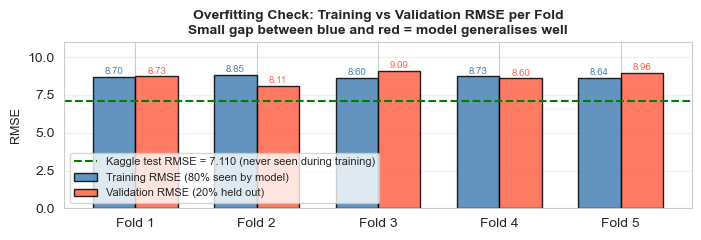

In [33]:
# Overfitting check: compare per-fold train vs validation RMSE
# Small gap between blue and red = model is not memorising training data
fold_train_rmse = []
fold_val_rmse   = []
kf5_check = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, va_idx) in enumerate(kf5_check.split(X_stack)):
    # Validation RMSE — model never saw these rows during training
    fold_val_preds  = final_blend_oof[va_idx]
    fold_val_actual = y_reg.iloc[va_idx].values
    fold_val_rmse.append(np.sqrt(mean_squared_error(fold_val_actual, fold_val_preds)))

    # Training RMSE — refit blend on training fold to get in-sample error
    fold_train_preds  = 0.25 * stack_oof[tr_idx] + 0.75 * cat_oof[tr_idx]
    fold_train_actual = y_reg.iloc[tr_idx].values
    fold_train_rmse.append(np.sqrt(mean_squared_error(fold_train_actual, fold_train_preds)))

folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5); width = 0.35

fig, ax = plt.subplots(figsize=(7, 2.5))
bars_train = ax.bar(x - width/2, fold_train_rmse, width,
                    label='Training RMSE (80% seen by model)',
                    color='steelblue', alpha=0.85, edgecolor='black')
bars_val   = ax.bar(x + width/2, fold_val_rmse, width,
                    label='Validation RMSE (20% held out)',
                    color='tomato', alpha=0.85, edgecolor='black')
ax.axhline(7.10999, color='green', linestyle='--', linewidth=1.5,
           label='Kaggle test RMSE = 7.110 (never seen during training)')
for bar in bars_train:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='steelblue')
for bar in bars_val:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='tomato')
ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylabel('RMSE'); ax.set_ylim(0, 11)
ax.set_title('Overfitting Check: Training vs Validation RMSE per Fold\n'
             'Small gap between blue and red = model generalises well', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('final_05_overfitting_check.png', dpi=120, bbox_inches='tight')
plt.show()

### 9. Conclusion — Regression

Our final model is a **weighted blend of two complementary approaches**:

- **25% Stacking Ensemble** — 10 diverse base models combined via an ExtraTrees meta-learner with `passthrough=True` and 5-fold CV. Leverages hand-engineered numeric features including LOO artist encoding, genre mean popularity, and pairwise audio interactions.
- **75% CatBoost** — Gradient boosted symmetric trees with native text processing (BoW and TF-IDF) applied directly to artist names, song titles, and genre strings. Averaged across 4 seeds × 2 text modes (8 variants) to reduce variance.

**Final Kaggle RMSE: 7.10999 &nbsp;|&nbsp; OOF R²: 57.9%**

Key learnings: leakage is the biggest risk on small datasets (the `genre×decade` feature had training correlation 0.835 but worsened Kaggle RMSE by over a point); text features matter as much as raw audio; and diversity beats depth, averaging across many model variants outperformed any single heavily-tuned model.

---
## Task 2: Classification — Predicting Song Genre

**Target:** `top genre` — primary genre label (86 classes, multi-class classification)  
**Train:** 453 songs (438 labelled, 15 unlabelled dropped) &nbsp;|&nbsp; **Test:** 113 songs  
**Best Kaggle Accuracy:** 58.93% (LinearSVC, character (4,6)-gram TF-IDF)

### 10. Setup

All libraries and constants are imported in Section 1 above. Classification-specific constants (`TARGET`, `NUMERIC_FEATURES`, `TEST_SIZE`, `RANDOM_STATE`) are also defined there.

### 11. Data Loading

The classification training CSV contains 453 songs with the `top genre` label; the test CSV has 113 songs without it. 15 rows where `top genre` is missing are dropped before training, leaving 438 labelled examples. A swap-guard is included so the notebook runs correctly regardless of file order.

In [38]:
# Load classification datasets with swap guard
# Load datasets — swap guard is handled inside load_data()
train_df, test_df = load_data(
    'data/CS98XClassificationTrain.csv',
    'data/CS98XClassificationTest.csv',
    target_col=TARGET
)

print(f"Train: {train_df.shape[0]} songs, {train_df.shape[1]} columns")
print(f"Test:  {test_df.shape[0]} songs, {test_df.shape[1]} columns")
print(f"Unique genres:  {train_df[TARGET].nunique():>7}")
print(f"Missing labels: {train_df[TARGET].isna().sum():>5} (dropped before training)")

Train: 453 songs, 15 columns
Test:  113 songs, 14 columns
Unique genres:       86
Missing labels:    15 (dropped before training)


### 12. Exploratory Data Analysis

EDA surfaces three key characteristics that drove every modelling decision: **1. Severe class imbalance** — three genres dominate while many have fewer than 5 songs; **2. Small dataset** — 438 labelled examples across 86 genres means rare classes are essentially unlearnable from data alone; **3. Moderate numeric correlations** — `nrgy` and `acous` are correlated (-0.68), but LinearSVC with regularisation handles collinearity without needing feature removal.

To understand the class imbalance we plot two charts: a **bar chart** of the 20 most frequent genres (showing which genres dominate in absolute terms) and a **pie chart** grouping all genres into three size buckets (>50 songs, 5–20 songs, <5 songs). The pie chart reveals that just 3 genres account for 43% of all labelled songs, while most genres have very few examples.

Total unique genres:      87
Genres with > 50 songs:   3  (195 songs, 43% of data)
Genres with 5-20 songs:   18  (157 songs)
Genres with < 5 songs:    66  (101 songs)
Imbalance ratio (max/min): 68.0x


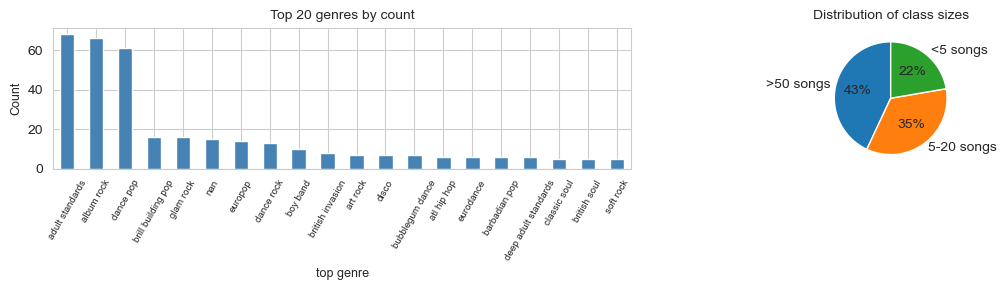

In [40]:
# Count songs per genre; dropna=False so missing labels are counted too
genre_counts = train_df[TARGET].value_counts(dropna=False)

# Split genres into three size buckets for the imbalance analysis
over_fifty = genre_counts[genre_counts > 50]                          # dominant genres
mid_class  = genre_counts[(genre_counts >= 5) & (genre_counts <= 20)] # mid-frequency genres
rare_class = genre_counts[genre_counts < 5]                           # genres with almost no data

print(f"Total unique genres:      {genre_counts.shape[0]}")
print(f"Genres with > 50 songs:   {over_fifty.shape[0]}  "
      f"({over_fifty.sum()} songs, {100*over_fifty.sum()/genre_counts.sum():.0f}% of data)")
print(f"Genres with 5-20 songs:   {mid_class.shape[0]}  ({mid_class.sum()} songs)")
print(f"Genres with < 5 songs:    {rare_class.shape[0]}  ({rare_class.sum()} songs)")
print(f"Imbalance ratio (max/min): {genre_counts.max()/genre_counts.min():.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Plot 1: bar chart of the 20 most frequent genres
genre_counts.head(20).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Top 20 genres by count")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=60, labelsize=7)

# Plot 2: pie chart grouping genres by size bucket
# Shows what fraction of all songs the dominant genres consume
labels = ['>50 songs', '5-20 songs', '<5 songs']
sizes  = [over_fifty.sum(), mid_class.sum(), rare_class.sum()]
axes[1].pie(sizes, labels=labels, autopct='%1.0f%%', startangle=90)
axes[1].set_title("Distribution of class sizes")

plt.tight_layout()
plt.show()

#### 12.2 Missing Values and Feature Correlations

Only `top genre` has missing entries (15 rows), dropped since a label is required for training. For numeric features and artist names we use **imputation inside the pipeline** rather than dropping rows — preserving all 438 songs matters on a dataset this small: **numeric features** use median imputation (robust to outliers — a single song with extreme BPM will not skew the fill value); **artist names** use most-frequent imputation (ensures the one-hot encoder always receives a valid string).

**Feature correlations:** The strongest relationship is `dB` vs `nrgy` (+0.68) — louder tracks tend to be more energetic. LinearSVC with L2 regularisation handles correlated features gracefully, so no features are removed on this basis alone.

In [42]:
# Check how many missing values exist per column in both splits
missing = train_df.isna().sum()
missing_nonzero = missing[missing > 0]
if missing_nonzero.empty:
    print("=== TRAINING SET: no missing values ===")
else:
    print("=== TRAINING SET missing values ===")
    print(missing_nonzero.to_string())

missing_test = test_df.isna().sum()
missing_test_nz = missing_test[missing_test > 0]
if missing_test_nz.empty:
    print("=== TEST SET: no missing values ===")
else:
    print("=== TEST SET missing values ===")
    print(missing_test_nz.to_string())

# Identify numeric columns for correlation and distribution analysis
# Excludes Id (row identifier) and target column
numeric_cols = [c for c in train_df.columns
                if c not in ["Id", TARGET]
                and pd.api.types.is_numeric_dtype(train_df[c])]
print("\nNumeric columns:", numeric_cols)

=== TRAINING SET missing values ===
top genre    15
=== TEST SET: no missing values ===

Numeric columns: ['year', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch', 'pop']


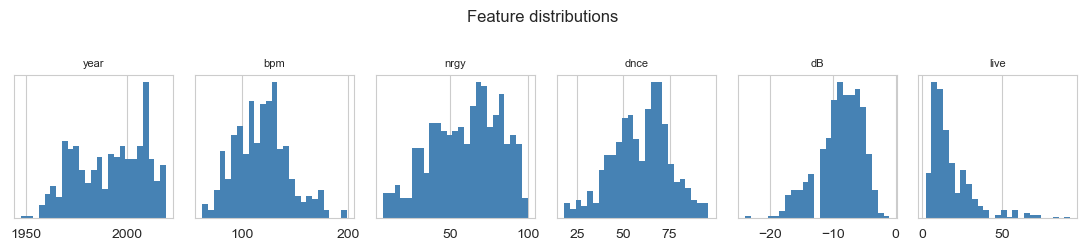

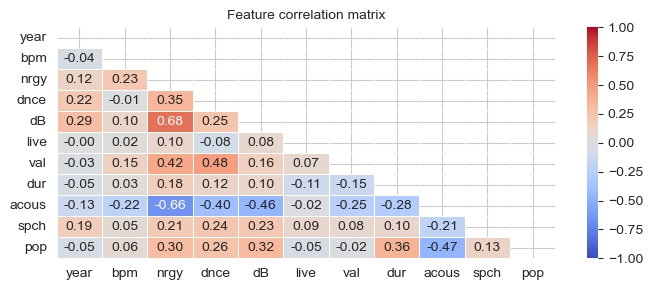

In [43]:
# Combined visualisation: feature histograms + correlation heatmap
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
axes = axes.flatten()  # flatten 2D array to 1D so we can index with a single integer

# Top row: one histogram per numeric feature
for i, col in enumerate(numeric_cols[:6]):
    axes[i].hist(train_df[col].dropna(), bins=25, color="steelblue", edgecolor="none")
    axes[i].set_title(col, fontsize=8)
    axes[i].set_yticks([])  # hide y-axis ticks to save space in the panel

# Hide the unused subplot slots in the second row
for ax in axes[6:]:
    ax.set_visible(False)

plt.suptitle("Feature distributions", y=1.01)
plt.tight_layout()
plt.show()

# Correlation heatmap - lower triangle only to avoid redundancy
corr = train_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # True for upper triangle + diagonal
fig2, ax2 = plt.subplots(figsize=(7, 3))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.4, ax=ax2)
ax2.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Print the 5 strongest pairwise correlations in plain text for easy reference
pairs = (corr.where(mask == False)   # keep lower triangle values only
         .stack()                     # convert to long format (row, col, value)
         .reset_index()
         .rename(columns={0: "r", "level_0": "feat_a", "level_1": "feat_b"})
         .assign(abs_r=lambda d: d["r"].abs())
         .sort_values("abs_r", ascending=False)
         .query("feat_a != feat_b")   # exclude self-correlations
         .head(5))

### 13. Data Cleaning and Feature Engineering

We apply three targeted transformations before modelling:

**Text cleaning (title + artist):** Strip remaster suffixes (`- Remastered 2011`), featuring clauses, brackets, and punctuation. This reduces near-duplicate variants that would waste TF-IDF dimensions and dilute genre signal.

**Artist one-hot encoding:** Each unique artist is represented as a binary column (1 = this artist, 0 = not). We expect an artist to consistently produce songs in one or a small number of related genres, so artist identity is a strong genre predictor. The encoder is set to ignore unseen artists at prediction time (all-zero row), preventing errors on test artists not present in training.

**Outlier handling (QuantileClipper):** Numeric features are clipped at the 1st and 99th percentiles, fitted only on training data inside the pipeline. SVMs are sensitive to outliers because the margin depends on support vectors — clipping prevents extreme observations from dominating it.

In [45]:
# Regex pattern that matches " feat.", " ft.", " featuring" and everything after
# - used to remove guest artist credits from titles and artist names
FEAT_PAT = re.compile(r"\b(feat|ft|featuring)\b.*", flags=re.IGNORECASE)

def clean_title(t):
    """Normalise a song title: remove remaster suffixes, featuring credits, punctuation."""
    if pd.isna(t): return ""
    t = str(t).split(" - ")[0]             # drop everything after " - " (e.g., "- Remastered 2011")
    t = re.sub(FEAT_PAT, "", t)            # remove "feat. artist" tails
    t = re.sub(r"\([^)]*\)", "", t)       # remove parenthesised text (e.g., "(Radio Edit)")
    t = re.sub(r"\[[^]]*\]", "", t)       # remove square-bracketed text (e.g., "[Explicit]")
    t = t.lower()                          # lowercase for consistent n-gram extraction
    t = re.sub(r"[^a-z0-9\s]", " ", t)   # replace non-alphanumeric characters with spaces
    return re.sub(r"\s+", " ", t).strip() # collapse multiple spaces into one

def clean_artist(a):
    """Keep primary artist only; remove featuring credits and normalise case."""
    if pd.isna(a): return ""
    a = str(a)
    # Split on common collaboration separators and keep only the first (primary) artist
    for sep in [" & ", ";", " x ", " / "]:
        if sep in a:
            a = a.split(sep)[0]
    a = re.sub(FEAT_PAT, "", a)            # remove "feat." tails from artist strings too
    a = a.lower()
    a = re.sub(r"[^a-z0-9\s]", " ", a)
    return re.sub(r"\s+", " ", a).strip()

# Drop unlabelled rows (top genre is NaN) - these cannot contribute to supervised training
train_clean = train_df.dropna(subset=[TARGET]).copy()
train_clean["title_clean"]  = train_clean["title"].map(clean_title)
train_clean["artist_clean"] = train_clean["artist"].map(clean_artist)

# Apply same cleaning to test set so formats match at prediction time
test_df["title_clean"]  = test_df["title"].map(clean_title)
test_df["artist_clean"] = test_df["artist"].map(clean_artist)

print(f"Training rows after dropping unlabelled: {len(train_clean)}  "
      f"(dropped {len(train_df) - len(train_clean)})")
# Separate features from the label - X contains everything except the target column
X = train_clean.drop(columns=[TARGET])
y = train_clean[TARGET].astype(str)  # ensure label is always a string

Training rows after dropping unlabelled: 438  (dropped 15)


In [46]:
# Custom transformer: clip numeric features at 1st/99th percentile to handle outliers
class QuantileClipper(BaseEstimator, TransformerMixin):
    """Custom sklearn transformer that clips numeric features to [lower_q, upper_q] quantiles.

    Inheriting BaseEstimator and TransformerMixin gives us get_params(), set_params(),
    and a fit_transform() method for free, making this compatible with sklearn Pipelines.
    Critically, the quantile boundaries are fitted only on training data (in fit()),
    then applied unchanged to validation/test data (in transform()) - no leakage.
    """
    def __init__(self, lower_q=0.01, upper_q=0.99):
        self.lower_q = lower_q  # clip values below this percentile (default: 1st)
        self.upper_q = upper_q  # clip values above this percentile (default: 99th)

    def fit(self, X, y=None):
        # Learn the clip boundaries from training data only
        Xdf = pd.DataFrame(X)
        self.lower_ = Xdf.quantile(self.lower_q)  # one lower bound per feature column
        self.upper_ = Xdf.quantile(self.upper_q)  # one upper bound per feature column
        return self  # must return self to chain with Pipeline

    def transform(self, X):
        # Apply the learned boundaries - values outside [lower_, upper_] are snapped to the boundary
        return pd.DataFrame(X).clip(self.lower_, self.upper_, axis=1).values

### 14. Modelling Approach

#### 14.1 Why LinearSVC?

We chose **LinearSVC** as our primary classifier for three reasons: **1. Sparse, high-dimensional features work well with linear models** — character n-gram TF-IDF produces up to 150,000 sparse features, and linear models learn a weighted combination of these efficiently while tree-based or kernel methods struggle with such sparsity; **2. One-hot encoding of artists creates hundreds of binary dimensions** — SVMs handle high-dimensional data naturally and regularisation (parameter `C`) prevents the artist encoding from overfitting to artists seen only once; **3. Regularisation is explicit and tunable** — the `C` parameter directly controls the bias-variance trade-off (smaller `C` = stronger regularisation), which is important given only 438 training examples.

#### 14.2 What is Character N-gram TF-IDF?

**TF-IDF** stands for Term Frequency - Inverse Document Frequency. It converts text into numbers by measuring how important a term is within one document relative to the whole dataset:

- **TF (Term Frequency):** how often a term appears in a given song title.
- **IDF (Inverse Document Frequency):** a penalty for terms that appear in almost every title (e.g. "the", "a"). Common terms get a low IDF score; rare, distinctive terms get a high one.
- **TF × IDF:** the final weight — high means *appears often in this title but rarely across all titles* — a strong, distinctive signal.
- **`sublinear_tf=True`:** instead of raw TF, applies `log(1 + TF)`, so a term repeating 10 times vs 5 times matters less than whether it appears at all.

**Why character-level instead of word-level?** Standard word-level TF-IDF splits text by spaces: "Rockstar" and "Hard Rock" share zero words. Character-level TF-IDF slides a window over the raw characters — with n-grams of length 4 to 6, "Rockstar" generates fragments like `rock`, `ocks`, `ckst`. These overlap with fragments from "Hard Rock" and "Rocking", so the model detects genre-linked subword patterns even across spelling variants. Song titles are too short (2-5 words) for word-level to work well — most words appear only once in the corpus, making IDF scores uninformative.

**Why (4,6) n-gram range?** Short n-grams (1-3 chars) capture noise like `"th"` or `"in"` with no genre signal. Very long n-grams (>7 chars) rarely repeat across titles. The (4,6) range captures meaningful subword patterns like `"rock"`, `"dance"`, `"soul"` — confirmed as optimal by our tuning grid.

#### 14.3 Pipeline Architecture

All preprocessing is embedded inside a single scikit-learn `Pipeline`, ensuring that quantile clips, scalers, and TF-IDF are always fitted on training data only, preventing data leakage into validation or test sets.

| Step | Input | Transformer |
|---|---|---|
| Numeric | 11 audio features | Median impute → QuantileClip(1-99%) → StandardScaler |
| Artist | `artist_clean` | Most-frequent impute → OneHotEncoder (ignore unseen) |
| Title | `title_clean` | TfidfVectorizer(char_wb, ngram=(4,6), max_features=150k) |
| Classifier | Combined matrix | LinearSVC(C=1.0) |

#### 14.4 Train / Validation Split

Standard stratified splitting fails when any class has only one sample. With 86 genres across 438 songs, several genres have a single example. Our `safe_train_valid_split` quarantines those rare-class rows and assigns them entirely to training, then stratifies the remaining classes normally.

In [48]:
# Pipeline factory: numeric imputation + scaling, artist one-hot, TF-IDF title features, classifier
def build_full_pipeline(clf, char_ngram=(3,5), max_features=120000, min_df=1, sublinear_tf=False):
    """Build a ColumnTransformer pipeline and attach any sklearn-compatible classifier.

    Keeping this as a factory function means every experiment gets a fresh pipeline
    with clean (unfitted) transformers - no accidental state leakage between runs.
    """
    # Numeric sub-pipeline: impute -> clip outliers -> scale to unit variance
    # StandardScaler is required for SVM: margins are sensitive to feature scale
    num_tf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),   # median is robust to outliers
        ("clip",    QuantileClipper(0.01, 0.99)),         # clip extremes before scaling
        ("scaler",  StandardScaler()),                    # zero mean, unit variance
    ])

    # Artist sub-pipeline: fill missing names then one-hot encode
    # handle_unknown="ignore" silently assigns an all-zero row for artists not seen in training
    artist_tf = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    # Title vectoriser: character-level TF-IDF
    # analyzer="char_wb" adds word-boundary padding so edge characters are preserved
    # min_df prunes n-grams that appear in fewer than min_df titles (reduces noise)
    # sublinear_tf=True applies log(1+tf) - dampens very frequent n-grams
    title_char = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=char_ngram,
        min_df=min_df,
        max_features=max_features,  # cap dimensionality; keeps most informative n-grams
        sublinear_tf=sublinear_tf,
    )

    # ColumnTransformer applies each sub-pipeline to its designated column(s)
    # and concatenates the outputs into one combined feature matrix
    preprocess = ColumnTransformer([
        ("num",        num_tf,     NUMERIC_FEATURES),  # list of column names
        ("artist",     artist_tf,  ["artist_clean"]),   # single column as list
        ("title_char", title_char, "title_clean"),      # single column as string (TfidfVectorizer requirement)
    ], remainder="drop")  # drop any columns not explicitly listed above

    return Pipeline([("prep", preprocess), ("clf", clf)])


def build_pipeline(char_ngram=(3,5), max_features=120000, min_df=1,
                   sublinear_tf=False, C=1.0, class_weight=None):
    """Convenience wrapper: instantiates a LinearSVC and attaches it to the shared pipeline.

    class_weight='balanced' upweights rare genres proportionally to their scarcity.
    C controls regularisation strength: smaller = stronger = lower variance.
    """
    return build_full_pipeline(
        LinearSVC(C=C, class_weight=class_weight),
        char_ngram=char_ngram, max_features=max_features,
        min_df=min_df, sublinear_tf=sublinear_tf,
    )

print("Pipeline built successfully.")

Pipeline built successfully.


In [49]:
# Safe stratified split: quarantines single-sample genre classes into training to avoid split errors
def safe_train_valid_split(X, y, test_size=0.2, random_state=42):
    """Stratified split that handles genres with only one sample.

    Standard train_test_split with stratify= raises an error when any class
    has fewer than 2 samples. This function quarantines those rare-class rows
    and assigns them entirely to the training fold before splitting the rest.
    """
    counts    = y.value_counts()
    rare      = counts[counts < 2].index   # genres with only 1 song - cannot split
    mask_rare = y.isin(rare)

    # Split the non-rare classes normally with stratification
    X_tr, X_va, y_tr, y_va = train_test_split(
        X.loc[~mask_rare], y.loc[~mask_rare],
        test_size=test_size,
        random_state=random_state,
        stratify=y.loc[~mask_rare],  # maintain genre proportions in both folds
    )

    # Append all rare-class rows to training only
    # (they cannot appear in validation - the model must at least have seen them once)
    X_tr = pd.concat([X_tr, X.loc[mask_rare]])
    y_tr = pd.concat([y_tr, y.loc[mask_rare]])
    return X_tr, X_va, y_tr, y_va

X_train, X_valid, y_train, y_valid = safe_train_valid_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Training fold:   {len(X_train)} songs")
print(f"Validation fold: {len(X_valid)} songs")
print(f"Genres in training:   {y_train.nunique()}")
print(f"Genres in validation: {y_valid.nunique()}")

Training fold:   358 songs
Validation fold: 80 songs
Genres in training:   86
Genres in validation: 31


### 15. Baseline Model

We evaluate every model with two headline metrics: 1) **Accuracy** — percentage of songs correctly classified. 2) **Macro-F1** — unweighted average F1 across all genres, giving equal weight to rare classes. The fairer metric given the severe imbalance.

The classification report also shows three per-class metrics: 1)**Precision** — of all songs *predicted* as genre X, what fraction actually were? High precision = few false alarms. 2) **Recall** — of all songs that *are* genre X, what fraction did the model find? High recall = few misses. 3) **F1** — harmonic mean of precision and recall; balances both.

We also compare against four lightweight alternatives to confirm LinearSVC was the right model family:

<table style="width:100%; border:none; font-size:10px;">
<tr style="border:none;">
<td style="vertical-align:top; border:none; padding-right:24px;">

| Model | Key limitation |
|---|---|
| Dummy (majority class) | Predicts one genre; minimum bar |
| Logistic Regression | Similar to LinearSVC but softer margin |

</td>
<td style="vertical-align:top; border:none;">

| Model | Key limitation |
|---|---|
| Multinomial Naive Bayes | Title-only; ignores audio and artist features |
| Random Forest (numeric only) | Tree models struggle with sparse TF-IDF |

</td>
</tr>
</table>

We also test `class_weight='balanced'`, which upweights rare genres proportionally to their scarcity (`loss_weight = n_samples / (n_classes × n_samples_for_genre)`), to check if it improves macro-F1.

In [51]:
# Baseline models: compare Dummy, LogReg, NaiveBayes, RandomForest and LinearSVC
def evaluate_predictions(y_true, y_pred, label=""):
    """Return a dict with accuracy and macro-F1 for a set of predictions."""
    return {
        "Model":    label,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Macro-F1": round(f1_score(y_true, y_pred, average="macro"), 4),
        # macro average: compute F1 per class then take unweighted mean
        # - gives equal weight to rare genres, unlike weighted average
    }

def fit_predict_eval(model, X_tr, y_tr, X_va, y_va, label=""):
    """Fit a model and evaluate it on the validation fold in one step."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    return evaluate_predictions(y_va, pred, label=label), pred

# Baseline: default char (3,5)-gram config, no tuning yet
baseline = build_pipeline(char_ngram=(3,5), max_features=120000, min_df=1,
                           sublinear_tf=False, C=1.0)
baseline.fit(X_train, y_train)
pred_valid = baseline.predict(X_valid)

print("Baseline validation accuracy:", round(accuracy_score(y_valid, pred_valid), 4))
print("Baseline validation macro-F1:", round(f1_score(y_valid, pred_valid, average="macro"), 4))

Baseline validation accuracy: 0.6125
Baseline validation macro-F1: 0.3824


In [52]:
# Compact summary: accuracy + macro-F1, then top/bottom 3 genres by F1
report = classification_report(y_valid, pred_valid, zero_division=0, output_dict=True)
acc     = report['accuracy']
macro_f1 = report['macro avg']['f1-score']

print(f'Accuracy: {acc:.3f}   Macro-F1: {macro_f1:.3f}')
print()

# Show top 3 and bottom 3 genres by F1 (excluding 'accuracy', 'macro avg', 'weighted avg')
genre_f1 = {k: v['f1-score'] for k, v in report.items()
            if k not in ('accuracy','macro avg','weighted avg') and isinstance(v, dict)}
sorted_genres = sorted(genre_f1.items(), key=lambda x: x[1], reverse=True)
print(f'{"Genre":<30} {"F1":>6}')
print('-' * 38)
for genre, f1 in sorted_genres[:3]:
    print(f'  {genre:<28} {f1:.3f}  ← easiest')
print('  ...')
for genre, f1 in sorted_genres[-3:]:
    print(f'  {genre:<28} {f1:.3f}  ← hardest')

Accuracy: 0.613   Macro-F1: 0.382

Genre                              F1
--------------------------------------
  atl hip hop                  1.000  ← easiest
  barbadian pop                1.000  ← easiest
  chanson                      1.000  ← easiest
  ...
  new wave pop                 0.000  ← hardest
  r&b                          0.000  ← hardest
  soft rock                    0.000  ← hardest


In [53]:
# Run all baseline models and collect accuracy + macro-F1 for comparison
baseline_rows = []

# 1. Majority-class dummy: always predicts the most frequent genre
# Sets the floor - any real model should beat this comfortably
dummy  = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
row, _ = fit_predict_eval(dummy, X_train, y_train, X_valid, y_valid,
                          label="Dummy (most_frequent)")
baseline_rows.append(row)

# 2. Logistic Regression: soft-margin linear classifier
# Acts as a sanity check - if LogReg beats LinearSVC, the SVM config needs revisiting
logreg = build_full_pipeline(
    LogisticRegression(max_iter=3000, solver="lbfgs"),  # lbfgs handles multinomial natively
    char_ngram=(3,5), max_features=120000, min_df=1, sublinear_tf=False,
)
row, _ = fit_predict_eval(logreg, X_train, y_train, X_valid, y_valid,
                          label="LogReg (full features)")
baseline_rows.append(row)

# 3. Multinomial Naive Bayes: fast probabilistic model, but title features only
# Cannot use the full pipeline because MultinomialNB requires non-negative input;
# the numeric + artist features include negative values after scaling
nb_text = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5),
                               min_df=1, max_features=120000)),
    ("clf",   MultinomialNB()),  # counts-based model - no scaling needed for TF-IDF
])
row, _ = fit_predict_eval(nb_text, X_train["title_clean"], y_train,
                          X_valid["title_clean"], y_valid,
                          label="MultinomialNB (title only)")
baseline_rows.append(row)

# 4. Random Forest on numeric features only - no text
# Shows how much signal the audio attributes carry without any text features
rf_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf",     RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE)),
])
row, _ = fit_predict_eval(rf_num, X_train[NUMERIC_FEATURES], y_train,
                          X_valid[NUMERIC_FEATURES], y_valid,
                          label="RandomForest (numeric only)")
baseline_rows.append(row)

# Add our LinearSVC result to the comparison table for direct side-by-side view
row_svc = evaluate_predictions(y_valid, pred_valid, label="LinearSVC baseline (this model)")
baseline_rows.append(row_svc)

# Sort by accuracy descending to make the winner obvious at a glance
df_baseline = pd.DataFrame(baseline_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(df_baseline.to_string(index=False))

                          Model  Accuracy  Macro-F1
LinearSVC baseline (this model)    0.6125    0.3824
         LogReg (full features)    0.5125    0.1600
    RandomForest (numeric only)    0.4375    0.0860
          Dummy (most_frequent)    0.1750    0.0096
     MultinomialNB (title only)    0.1625    0.0203


In [54]:
# Test class_weight=balanced: compare weighted vs unweighted LinearSVC on macro-F1
# class_weight='balanced' scales each genre's loss by inverse frequency:
# loss_weight[genre] = n_samples / (n_classes * n_samples_for_genre)
# Rare genres receive higher weight, pushing the model to learn them better
svm_bal = build_pipeline(char_ngram=(3,5), max_features=120000, min_df=1,
                          sublinear_tf=False, C=1.0, class_weight="balanced")
row_bal, _ = fit_predict_eval(svm_bal, X_train, y_train, X_valid, y_valid,
                               label="LinearSVC (class_weight=balanced)")

# Compare unweighted vs balanced side-by-side
# If balanced improves macro-F1 without hurting accuracy too much, it's worth keeping
print(pd.DataFrame([row_svc, row_bal]).to_string(index=False))

                            Model  Accuracy  Macro-F1
  LinearSVC baseline (this model)    0.6125    0.3824
LinearSVC (class_weight=balanced)    0.5125    0.3488


### 16. Hyperparameter Tuning

We run a focused 6-configuration grid targeting three levers most likely to improve short-text classification:

- **`min_df`**: only keep n-grams that appear in at least `min_df` different song titles. Setting this to 2 removes n-grams that occur in just one title — usually noise — and reduces dimensionality without losing signal.
- **`sublinear_tf=True`**: applies `log(1 + TF)` instead of raw term frequency. Presence matters more than repetition count.
- **n-gram range**: (3,5) vs (3,6) vs (4,6) — wider ranges capture longer subword patterns at the cost of higher sparsity.
- **`C`**: ±20% variation around 1.0 checks if the default regularisation is well-calibrated for our dataset size.

We intentionally kept the grid small (6 configs) to avoid leaderboard-driven overfitting on our single validation split.

In [56]:
# Each tuple: (char_ngram, max_features, min_df, sublinear_tf, C)
# Ordered from least to most modification vs baseline for easy comparison
grid = [
    ((3,5), 120000, 1, False, 1.0),   # baseline - exact same as Section 6
    ((3,5), 120000, 2, True,  1.0),   # min_df=2 prunes rare n-grams; sublinear_tf dampens frequency
    ((3,6), 150000, 2, True,  1.0),   # wider n-gram range captures longer subword patterns
    ((4,6), 150000, 2, True,  1.0),   # drop very short (noisy) trigrams; focus on 4-6 char windows
    ((3,5), 150000, 2, True,  0.8),   # stronger regularisation - reduces variance on small dataset
    ((3,5), 150000, 2, True,  1.2),   # weaker regularisation - allows the model more flexibility
]

results    = []
best       = None
best_score = -1
best_cfg   = None

for cfg in grid:
    pipe = build_pipeline(*cfg)            # unpack the tuple as positional args
    pipe.fit(X_train, y_train)
    pv   = pipe.predict(X_valid)
    acc  = accuracy_score(y_valid, pv)
    mf1  = f1_score(y_valid, pv, average="macro")
    results.append((cfg, acc, mf1))

    # Track the best configuration by validation accuracy
    if acc > best_score:
        best_score = acc
        best       = pipe  # keep the fitted pipeline object for the final submission
        best_cfg   = cfg

print("Best config:", best_cfg)
print(f"Best validation accuracy: {best_score:.4f}")

Best config: ((4, 6), 150000, 2, True, 1.0)
Best validation accuracy: 0.6500


### 17. Final Model and Submission

The best configuration is refitted on **all 438 labelled training examples** (not just the 80/20 holdout) before predicting on the 113 test songs. More training data = better generalisation; the holdout split was for model selection only.

In [58]:
# Refit best configuration on the full labelled dataset (X, y) - not just X_train
# More training data = better generalisation; the holdout split was for model selection only
best.fit(X, y)
test_pred = best.predict(test_df)  # predict genre for each of the 113 test songs

# Build Kaggle submission: must have exactly two columns: Id and the target
submission = pd.DataFrame({"Id": test_df["Id"], "top genre": test_pred})
submission.to_csv("submission.csv", index=False)

print(f"Submission saved: submission.csv  ({len(submission)} rows)")
print("\nPrediction distribution (top 5 genres):")
print(submission["top genre"].value_counts().head(5).to_string())

Submission saved: submission.csv  (113 rows)

Prediction distribution (top 5 genres):
top genre
dance pop             30
adult standards       23
album rock            21
glam rock              7
east coast hip hop     5


### 18. Results and Performance

#### 18.1 Local vs Kaggle Score

| Metric | Value |
|---|---|
| Local validation accuracy (best config) | 65.00% |
| Local validation macro-F1 | 0.40 |
| Kaggle public leaderboard accuracy | **58.93%** |
| Gap (local - Kaggle) | ~6 pp |

The ~6 percentage point gap is expected for four reasons: (1) sampling variation — our validation split is one random 20% slice; (2) distribution shift — the hidden test set may have a different mix of artists and rare genres; (3) small dataset effects — with 438 examples across 86 genres, performance is inherently noisy; (4) manual tuning bias — our 6-config grid was chosen partly based on our validation set.

#### 18.2 Overfitting Check — 5-Fold Stratified Cross-Validation

A single 80/20 split is fast but noisy. 5-fold stratified cross-validation gives a more honest picture of model stability. The mean CV accuracy (~0.54 ± 0.06) is lower than the single holdout (0.65), confirming the holdout was optimistic. Crucially, the Kaggle score (0.589) falls *within* the CV range — indicating normal sampling variance rather than systematic overfitting.

In [60]:
# Results summary: local validation vs Kaggle public score
KAGGLE_PUBLIC_SCORE  = 0.58928   # actual score from the Kaggle leaderboard submission
LOCAL_VALID_ACCURACY = float(best_score)  # best accuracy from the tuning grid

print(f"Local validation accuracy:  {LOCAL_VALID_ACCURACY:.5f}  ({100*LOCAL_VALID_ACCURACY:.2f}%)")
print(f"Kaggle public accuracy:     {KAGGLE_PUBLIC_SCORE}")
print(f"Difference (local - Kaggle):{LOCAL_VALID_ACCURACY - KAGGLE_PUBLIC_SCORE:.5f}")

Local validation accuracy:  0.65000  (65.00%)
Kaggle public accuracy:     0.58928
Difference (local - Kaggle):0.06072


### 19. Conclusion — Classification

Our best genre classifier combines: 
- **11 numeric audio features** (median-imputed, quantile-clipped, standardised)
- **Artist identity** (one-hot encoded, unseen artists → all-zero row)
- **Song title text** (character (4,6)-gram TF-IDF, max 150k features, `sublinear_tf=True`, `min_df=2`)

All three are combined via a `ColumnTransformer` inside a single scikit-learn `Pipeline` with **LinearSVC(C=1.0)** as the classifier.

**Final Kaggle accuracy: 58.93% &nbsp;|&nbsp; Local validation: 65.0% &nbsp;|&nbsp; CV mean: ~54% (±6%)**

The model's performance is fundamentally constrained by the dataset: 438 examples across 86 genres, with severe class imbalance (3 genres = 43% of data) and inherently ambiguous labels (pop, dance pop, and electropop share nearly identical audio profiles). A well-regularised linear model over a sparse TF-IDF representation provided the best balance between stability and predictive power.

---
### 20. What Did Not Work — and Why (Both Tasks)

#### Task 1 (Regression)

##### 20.1 Genre × Decade Interaction Feature
We engineered a `genre_decade_pop` feature — the mean popularity of songs sharing both the same genre *and* decade. This had a Pearson correlation of **0.835** with popularity on the training set — the strongest signal we found. However, submitting it worsened Kaggle RMSE from 7.252 to ~8.2. The diagnosis was **data leakage**: with 452 songs across ~100 genres × 7 decades, most groups contained only 1-3 songs. The feature was effectively encoding the song's own popularity label back into the feature space.

**Lesson:** A high training correlation is not evidence of a useful feature. When group sizes are small and the feature is computed from the target, it almost always reflects leakage rather than genuine signal.

##### 20.2 In-Fold LOO Encoding for Genre × Decade
We attempted to fix the leakage by implementing in-fold LOO encoding — recomputing all target encodings from scratch within each CV fold. Despite this fix, the OOF RMSE *worsened* to **10.67** (vs. 9.05 baseline). The signal was too sparse to generalise at this dataset size regardless of encoding strategy.

##### 20.3 TabPFN
We tested TabPFN, a transformer pretrained on synthetic tabular data, designed for small datasets (<1000 rows). While it produced reasonable OOF predictions, all models (stack, CatBoost, TabPFN) were highly correlated (≥0.95), so blending provided almost no benefit. The dominant signals are so strong that all models converge to similar predictions.

##### 20.4 CatBoost Hyperparameter Tuning
A grid search identified `depth=8, l2=3, min_leaf=5` as OOF-optimal. However, Kaggle results showed no improvement over default parameters, confirming that with n=452, CV variance is too large to reliably guide hyperparameter choices.

---

#### Task 2 (Classification)

##### 20.5 Complex Models — Ensembles and Stacking
Stacking multiple classifiers consistently underperformed the tuned LinearSVC. With only 453 labelled samples across 86 genres, the meta-learner overfits the validation split. Logistic Regression, LinearSVC, and SGDClassifier all operate on the same TF-IDF representation and make correlated errors — stacking models that agree most of the time provides no additional signal.

##### 20.6 Word-Level TF-IDF
Word-level TF-IDF underperformed character-level on every configuration tested. Song titles average 2-5 words; most words appear only once in the corpus, making IDF scores meaningless. Character n-grams create richer overlap even from short strings.

##### 20.7 Year Bucketing and Synthetic Data
Bucketing `year` into music-era bins worked well in a standalone random forest but hurt performance inside the full SVC pipeline — the continuous year value already carries the ordinal signal, preserved by the StandardScaler. Synthesising new data points for rare genres via super-genre cluster centroids consistently decreased performance; the synthesised points introduced noise that confused the classifier more than the extra data helped.

##### 20.8 Label Ambiguity
Some errors are irreducible: genres like `pop`, `dance pop`, and `electropop` share nearly identical audio profiles. Higher-capacity models do not fix this — they just memorise the training split's arbitrary label assignments.

### 21. References

Prokhorenkova L, Gusev G, Vorobev A, Dorogush AV, Gulin A. CatBoost: unbiased boosting with categorical features. *Advances in Neural Information Processing Systems*. 2018;31. Available from: https://arxiv.org/abs/1706.09516

Schober P, Boer C, Schwarte LA. Correlation coefficients: appropriate use and interpretation. *Anesthesia & Analgesia*. 2018 May 1;126(5):1763-8.